# Aprendizaje Automático I

## Trabajo Práctico: Predicción de precios de casas

### Facultad de Ciencias Exactas, Ingeniería y Agrimensura (FCEIA) - Universidad Nacional de Rosario (UNR)

**Integrantes:** Gimbatti, Longo, Paredes

---

### Contenidos

1. Configuración del entorno
2. Carga e inspección estructural del dataset
3. Gestión de datos: nulos, duplicados y consistencia
4. División train / test
5. Validación experimental de la eliminación de registros
6. Análisis descriptivo
7. Pruebas de normalidad
8. Correlaciones y colinealidad
9. Detección de outliers
10. Estandarización
11. Conclusiones y próximos pasos

---

## 1. Configuración del entorno

Importamos las librerías necesarias y fijamos una semilla (`RANDOM_STATE`) para que todos los resultados del notebook sean reproducibles.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Semilla fija para que los resultados sean reproducibles
RANDOM_STATE = 42

# Configuración global de visualización
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 100})
sns.set_theme(style='whitegrid', palette='viridis')
pd.set_option('display.max_columns', None)

---

## 2. Carga e inspección estructural del dataset

El dataset `house-prices-tp.csv` contiene información de viviendas de Boston:

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `CRIM` | Continua | Tasa de criminalidad per cápita por ciudad |
| `ZN` | Continua | Proporción de terreno residencial zonificado para lotes de más de 25.000 pies² |
| `INDUS` | Continua | Proporción de acres de negocios no minoristas por ciudad |
| `CHAS` | Binaria | 1 si el tramo limita con el río Charles, 0 si no |
| `NOX` | Continua | Concentración de óxidos de nitrógeno (partes por 10 millones) |
| `RM` | Continua | Número promedio de habitaciones por vivienda |
| `AGE` | Continua | Proporción de viviendas ocupadas por sus propietarios construidas antes de 1940 |
| `DIS` | Continua | Distancia ponderada a cinco centros de empleo de Boston |
| `RAD` | Ordinal | Índice de accesibilidad a las autopistas radiales |
| `TAX` | Continua | Tasa de impuesto a la propiedad por cada USD 10.000 |
| `PTRATIO` | Continua | Proporción alumno-maestro por ciudad |
| `B` | Continua | $1000(B_k - 0.63)^2$, donde $B_k$ es la proporción de población negra por ciudad |
| `LSTAT` | Continua | % de población de menor estatus socioeconómico |
| **`MEDV`** | **Continua (target)** | **Valor mediano de las viviendas, en miles de USD** |

In [48]:
# Carga del dataset
df = pd.read_csv("house-prices-tp.csv")

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 556 filas x 14 columnas


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


In [49]:
# Vista de una muestra aleatoria de registros
display(df.sample(5, random_state=RANDOM_STATE))

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
457,0.10574,0.0,27.74,0.0,0.609,5.983,98.8,1.8681,4.0,711.0,20.1,390.11,18.07,13.6
167,9.59571,0.0,18.10,0.0,0.693,6.404,100.0,1.6390,24.0,666.0,20.2,376.11,20.31,12.1
55,2.81838,0.0,18.10,0.0,0.532,5.762,40.3,4.0983,24.0,666.0,20.2,392.92,10.42,21.8
245,0.09849,0.0,25.65,0.0,0.581,5.879,95.8,2.0063,2.0,188.0,19.1,379.38,17.58,18.8
70,0.02187,60.0,2.93,0.0,0.401,6.800,9.9,6.2196,1.0,265.0,15.6,393.37,5.03,31.1


In [50]:
# Paneo general: tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [51]:
# Separación de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numéricas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categóricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numéricas (14): ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
Variables categóricas (0): []


Las 14 columnas son numéricas (`float64`), así que no hace falta codificar variables categóricas. Hay que tener en cuenta que dos de ellas, aunque numéricas, no son continuas: `CHAS` es una variable binaria (dummy) y `RAD` es un índice que solo toma valores enteros.

---

## 3. Gestión de datos: nulos, duplicados y consistencia

### 3.1 Patrones de datos faltantes


Identificar el patrón es importante para decidir si conviene eliminar los registros o imputarlos.

In [52]:
# Reporte de valores nulos por columna
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos.round(2),
    'Tipo': df.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} ({nulos.sum() / df.size * 100:.2f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        23            4.14  float64
ZN          22            3.96  float64
INDUS       15            2.70  float64
CHAS        23            4.14  float64
NOX         24            4.32  float64
RM          21            3.78  float64
AGE         24            4.32  float64
DIS         15            2.70  float64
RAD         28            5.04  float64
TAX         18            3.24  float64
PTRATIO     28            5.04  float64
B           22            3.96  float64
LSTAT       22            3.96  float64
MEDV        21            3.78  float64

Total de celdas con nulos: 306 (3.93% del dataset)


Encontramos entre 15 y 28 observaciones con valores faltantes en cada una de las características, incluida la variable objetivo `MEDV` (21 faltantes). En total falta el 3,93% de las celdas.

Que falten datos en las 14 columnas, en cantidades parecidas, es poco habitual en datos reales: normalmente los faltantes tienen una causa y se concentran en algunas variables. Para entender mejor el patrón, contamos cuántos nulos tiene cada registro.

### 3.2 Distribución de los nulos por registro

In [53]:
# Cantidad de registros según cuántos valores nulos tienen
# (índice = cantidad de nulos en el registro, valor = cantidad de registros)
display(df.isna().sum(axis=1).value_counts().sort_index())

0     506
1       5
2       3
3      11
4       3
5       3
6       2
7       5
8       4
9       4
10      1
11      3
12      2
13      3
14      1
Name: count, dtype: int64

**Observación:** 506 registros están completos, y los 306 valores faltantes se concentran en solo 50 registros, que tienen entre 1 y 14 nulos cada uno (uno de ellos está completamente vacío).

Si los faltantes fueran aleatorios (MCAR), con un 3,93% de celdas faltantes esperaríamos muchos registros con 1 solo nulo y prácticamente ninguno con 7 o más. Observamos lo contrario: solo 5 registros con 1 nulo y 23 registros con 7 o más. Los faltantes no son aleatorios: se concentran en un grupo particular de registros. En las secciones siguientes analizamos si ese grupo tiene otras características en común.

### 3.3 Registros duplicados

In [54]:
# Analizamos duplicados
n_duplicados = df.duplicated().sum()
print(f'Registros duplicados: {n_duplicados} ({n_duplicados / len(df) * 100:.2f}%)')

Registros duplicados: 0 (0.00%)


Llegamos a la conclusión de que no hay observaciones duplicadas en el conjunto de datos.

### 3.4 Consistencia de la variable RAD

`RAD` es un **índice** de accesibilidad a las autopistas radiales: es un código asignado por categoría, así que solo puede tomar valores enteros. Un valor como 2,4 no tiene sentido, de la misma forma que no tiene sentido un diamante con dimensión 0. Verificamos si esto se cumple.

In [55]:
print("Cantidad de valores únicos de RAD:")
display(df["RAD"].nunique())
print("Frecuencia de valores de RAD:")
display(df["RAD"].value_counts())

Cantidad de valores únicos de RAD:


31

Frecuencia de valores de RAD:


RAD
24.000000    132
5.000000     115
4.000000     110
3.000000      38
6.000000      26
8.000000      24
2.000000      24
1.000000      20
7.000000      17
10.554892      1
14.638330      1
17.000150      1
6.850123       1
22.069511      1
1.307128       1
17.164570      1
10.168701      1
21.900776      1
15.239579      1
4.811748       1
19.266891      1
3.056548       1
23.510213      1
17.110181      1
18.177503      1
2.402424       1
4.528569       1
2.573615       1
22.328313      1
14.195528      1
20.416908      1
Name: count, dtype: int64

In [56]:
# Los valores reales son únicamente números enteros, ya que lógicamente no existen autopistas
# con números con coma. Comparamos los valores de RAD en registros completos y en registros con nulos
sucias = df.isna().any(axis=1)
print('RAD en registros completos:', sorted(df.loc[~sucias, 'RAD'].unique()))
print()
print('RAD en registros con nulos:', sorted(df.loc[sucias, 'RAD'].dropna().round(2).unique()))

RAD en registros completos: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(24.0)]

RAD en registros con nulos: [np.float64(1.31), np.float64(2.4), np.float64(2.57), np.float64(3.06), np.float64(4.53), np.float64(4.81), np.float64(6.85), np.float64(10.17), np.float64(10.55), np.float64(14.2), np.float64(14.64), np.float64(15.24), np.float64(17.0), np.float64(17.11), np.float64(17.16), np.float64(18.18), np.float64(19.27), np.float64(20.42), np.float64(21.9), np.float64(22.07), np.float64(22.33), np.float64(23.51)]


In [57]:
# ¿Dónde aparecen los valores de RAD no enteros?
rad_no_entero = df["RAD"].notna() & (df["RAD"] % 1 != 0)
print(f"Valores de RAD no enteros: {rad_no_entero.sum()}")
print(f"  en registros completos: {(rad_no_entero & ~sucias).sum()}")
print(f"  en registros con nulos: {(rad_no_entero & sucias).sum()}")

Valores de RAD no enteros: 22
  en registros completos: 0
  en registros con nulos: 22


**Observación:** en los registros completos, `RAD` toma únicamente los valores {1, 2, 3, 4, 5, 6, 7, 8, 24}. El salto de 8 a 24 confirma que es un código por categorías y no una medición continua. Los 22 valores no enteros (por ejemplo 2,40 o 17,16) aparecen **todos** en registros con nulos. Es decir, esos registros, además de estar incompletos, contienen valores imposibles.

### 3.6 Relación con el precio en registros completos e incompletos

Si los 50 registros con nulos fueran viviendas reales a las que simplemente les faltan algunos datos, deberían mostrar las mismas relaciones con el precio que el resto. Comparamos la correlación de cada variable con `MEDV` en los dos grupos.

In [59]:
# Correlación de Pearson de cada variable con MEDV, en cada grupo de registros
corr_completos = df.loc[~sucias].corr()['MEDV'].drop('MEDV')
corr_con_nulos = df.loc[sucias].corr()['MEDV'].drop('MEDV')

comparacion_corr = pd.DataFrame({
    'Registros completos': corr_completos.round(3),
    'Registros con nulos': corr_con_nulos.round(3)
})
comparacion_corr

,Registros completos,Registros con nulos
CRIM,-0.388,0.041
ZN,0.360,0.004
INDUS,-0.484,0.307
CHAS,0.175,0.245
NOX,-0.427,0.278
RM,0.695,-0.117
AGE,-0.377,-0.409
DIS,0.250,-0.201
RAD,-0.382,0.357
TAX,-0.469,0.048


**Observación:** las relaciones más fuertes con el precio desaparecen o se invierten en los registros con nulos: `LSTAT` pasa de −0,74 a −0,12, `RM` de +0,70 a −0,12 y `PTRATIO` de −0,51 a +0,12. Esos registros no se comportan como viviendas reales.

### 3.7 Censura de la variable objetivo (MEDV)

In [60]:
# Observamos un truncamiento de MEDV en 50
display(df['MEDV'].value_counts().head())
print(f"Máximo de MEDV: {df['MEDV'].max()}")

MEDV
50.0    16
25.0     8
21.7     7
22.0     7
23.1     7
Name: count, dtype: int64

Máximo de MEDV: 50.0


**Observación:** 16 registros tienen `MEDV` exactamente igual a 50 (USD 50.000), el valor máximo, con una frecuencia muy superior a la de cualquier otro valor. La variable está **censurada**: las viviendas que valían USD 50.000 o más se registraron como 50.

Por eso esperamos que el modelo tienda a **subestimar** los precios de las casas más caras. Aun así, decidimos conservar estos registros: eliminarlos nos dejaría con un rango más acotado y con menos información sobre cómo predecir precios altos.

### 3.8 Decisión: eliminación de los 50 registros con nulos

Juntando los análisis anteriores, los 50 registros con valores nulos:

1. **Concentran todos los faltantes**, que no se distribuyen como lo harían si fueran aleatorios (sección 3.2).
2. **Contienen todos los valores imposibles de `RAD`** (sección 3.4).
4. **No respetan las relaciones con el precio** que muestra el resto del dataset (sección 3.6).

Las tres evidencias son independientes entre sí y señalan exactamente a los mismos 50 registros. Concluimos que no son viviendas reales con datos incompletos, sino **registros corruptos**.

Por eso no corresponde imputarlos: imputar sirve para completar datos que faltan en observaciones válidas, pero acá los valores que sí están presentes tampoco son confiables. Además, 21 de estos registros no tienen `MEDV`, y un registro sin target no puede usarse ni para entrenar ni para evaluar el modelo.

**Decisión:** eliminamos los 50 registros y trabajamos con los 506 registros completos. En la sección 5 validamos esta decisión de forma experimental.

In [61]:
# Eliminación de los registros con nulos
print("Cantidad de registros antes de la eliminación de nulos: ", df.shape[0])
df_limpio = df[df.isna().sum(axis=1) == 0].copy()
print("Cantidad de registros después de la eliminación de nulos:", df_limpio.shape[0])

Cantidad de registros antes de la eliminación de nulos:  556
Cantidad de registros después de la eliminación de nulos: 506


In [62]:
# Verificación del dataset limpio
print('Verificación del dataset limpio:')
print('=' * 50)
print(f"Nulos restantes:                       {df_limpio.isna().sum().sum()}")
print(f"Registros duplicados:                  {df_limpio.duplicated().sum()}")
print(f"Valores de RAD:                        {sorted(df_limpio['RAD'].unique())}")
print(f"Valores de CHAS:                       {sorted(df_limpio['CHAS'].unique())}")
print(f"Registros con precisión anómala:       {(valores_anomalos_por_fila.loc[df_limpio.index] > 0).sum()}")

Verificación del dataset limpio:
Nulos restantes:                       0
Registros duplicados:                  0
Valores de RAD:                        [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(24.0)]
Valores de CHAS:                       [np.float64(0.0), np.float64(1.0)]
Registros con precisión anómala:       0


---

## 4. División train / test

Dividimos el dataset limpio en entrenamiento (80%) y prueba (20%) **antes** de seguir con el análisis. Todos los análisis que usemos para tomar decisiones de modelado (distribuciones, correlaciones, outliers, estandarización) se hacen solo sobre el conjunto de entrenamiento. Si miráramos el conjunto de prueba para tomar decisiones, la información del test se filtraría al modelo (*data leakage*) y la evaluación final dejaría de ser una medición honesta sobre datos nunca vistos.

In [63]:
# X: matriz de características (features) | y: variable objetivo (target)
X = df_limpio.drop(columns=['MEDV'])
y = df_limpio['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((404, 13), (102, 13), (404,), (102,))

---

## 5. Validación experimental de la eliminación de registros

En la sección 3.8 decidimos eliminar los 50 registros con nulos. Una alternativa que habíamos considerado era un criterio más conservador:

- eliminar los registros sin target,
- eliminar los registros con 7 o más features nulas (la mitad o más),
- redondear `RAD` al entero más cercano y eliminar los registros en los que el resultado no pertenece a {1, …, 8, 24}.

Con ese criterio se conservaban **14 registros con nulos**, que había que imputar. En esta sección comprobamos de forma experimental cuál de las dos opciones es mejor, comparando dos escenarios:

- **Escenario A:** entrenar solo con registros completos (nuestra decisión).
- **Escenario B:** entrenar con esos mismos registros más los 14 registros imputados.

### 5.1 Registros que conservaba el criterio anterior

In [ ]:
# Criterio anterior: MEDV faltante -> no hay target, no sirve para entrenar ni evaluar
medv_faltante = df["MEDV"].isna()
# Registros con la mitad o más de las features nulas (7 o más NA)
demasiados_na = df.isna().sum(axis=1) > 6

a_eliminar = medv_faltante | demasiados_na
df_criterio_anterior = df.loc[~a_eliminar].copy()

RAD_VALIDOS = [1, 2, 3, 4, 5, 6, 7, 8, 24]

# 1) Redondeamos RAD: 6.85 -> 7 (los NaN quedan como NaN)
df_criterio_anterior["RAD"] = np.round(df_criterio_anterior["RAD"])

# 2) Eliminamos los registros cuyo RAD, ya redondeado, no pertenece al dominio válido
rad_fuera_de_dominio = df_criterio_anterior["RAD"].notna() & ~df_criterio_anterior["RAD"].isin(RAD_VALIDOS)
df_criterio_anterior = df_criterio_anterior.loc[~rad_fuera_de_dominio]

# Los registros con nulos que conservaba este criterio
filas_14 = df_criterio_anterior[df_criterio_anterior.isna().any(axis=1)]

print(f"Registros que conservaba el criterio anterior: {len(df_criterio_anterior)}")
print(f"De ellos, registros con nulos a imputar:       {len(filas_14)}")


Registros que conservaba el criterio anterior: 520
De ellos, registros con nulos a imputar:       14
De ellos, con precisión anómala (sección 3.5): 14


### 5.2 Imputación numérica con KMeans

Para el escenario B necesitamos imputar los 14 registros. Usamos **KMeans**, como en el notebook de imputación de la materia. La hipótesis es que los registros similares en las variables observadas también son similares en las variables faltantes. KMeans agrupa los registros en $k$ conglomerados resolviendo

Para evitar *data leakage*, KMeans se ajusta **solo con los registros completos del conjunto de entrenamiento**. Además, como KMeans trabaja con distancias, las variables se estandarizan antes de agrupar: si no, `TAX` (valores de cientos) dominaría sobre `NOX` (valores menores que 1).

In [65]:
def imputar_kmeans(X_referencia, X_a_imputar, k):
    # Estandarizamos con los datos de referencia (completos) y ajustamos KMeans sobre ellos
    scaler_km = RobustScaler().fit(X_referencia)
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(scaler_km.transform(X_referencia))
    centroides = km.cluster_centers_

    # Estandarizamos los registros a imputar (los NaN se conservan)
    Z = scaler_km.transform(X_a_imputar)
    Z_imputado = Z.copy()

    for i in range(len(Z)):
        observadas = ~np.isnan(Z[i])
        # Distancia a cada centroide usando solo las variables observadas del registro
        distancias = ((centroides[:, observadas] - Z[i, observadas]) ** 2).sum(axis=1)
        cluster = distancias.argmin()
        # Completamos las variables faltantes con el valor del centroide de su cluster
        Z_imputado[i, ~observadas] = centroides[cluster, ~observadas]

    # Volvemos a la escala original
    return pd.DataFrame(scaler_km.inverse_transform(Z_imputado),
                        columns=X_a_imputar.columns, index=X_a_imputar.index)

#### Selección de $k$: método del codo y coeficiente de silueta

Calculamos la **inercia** (suma de distancias cuadradas intra-cluster) para un rango de $k$ y buscamos el punto donde agregar más clusters deja de reducirla de forma significativa (el "codo"). Para validar la elección, también calculamos el **coeficiente de silueta**, que mide qué tan separados están los clusters: valores cercanos a 1 indican grupos compactos y bien diferenciados.

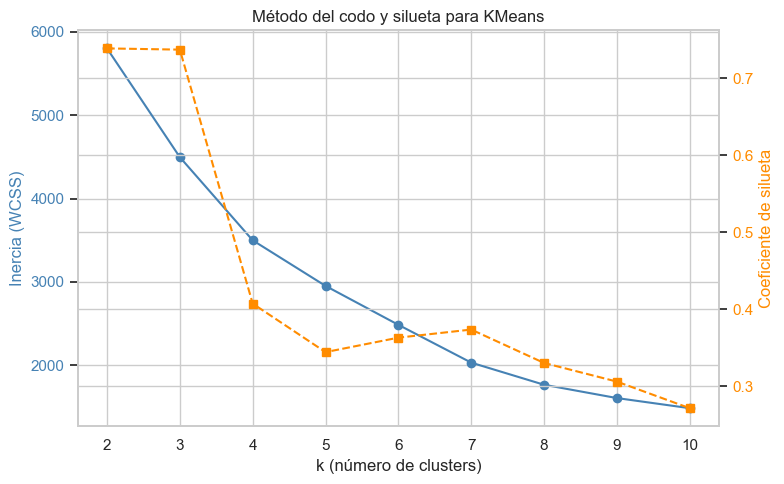

,k,inercia,silueta
0,2,5799.276,0.739
1,3,4495.589,0.737
2,4,3499.222,0.407
3,5,2952.972,0.344
4,6,2486.440,0.363
5,7,2033.360,0.373
6,8,1768.287,0.330
7,9,1608.771,0.306
8,10,1487.506,0.271


In [66]:
scaler_cluster = RobustScaler().fit(X_train)
X_scaled = scaler_cluster.transform(X_train)

k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(list(k_range), inertias, "o-", color="steelblue")
ax1.set_xlabel("k (número de clusters)")
ax1.set_ylabel("Inercia (WCSS)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(list(k_range), silhouettes, "s--", color="darkorange")
ax2.set_ylabel("Coeficiente de silueta", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

plt.title("Método del codo y silueta para KMeans")
plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(k_range), "inercia": inertias, "silueta": silhouettes}).round(3)

**Elección de $k$.** La curva de inercia no muestra un codo marcado: baja de forma gradual. La silueta es máxima en $k = 2$, pero dos grupos son demasiado generales para imputar 13 variables. El siguiente máximo de la silueta está en $k = 6$, en la zona donde la inercia empieza a aplanarse. Elegimos $k = 6$.

In [67]:
K_CHOSEN = 6

### 5.3 Evaluación del imputador con faltantes artificiales

Para medir qué tan bien imputa KMeans usamos el mismo método que el notebook de la materia: tomamos registros completos del train, les **ocultamos valores cuyo valor real conocemos**, los imputamos y comparamos con el valor verdadero. Como referencia (*baseline*), comparamos contra la imputación por **mediana**.

Para que la prueba sea realista, a cada registro le ocultamos los valores siguiendo el mismo patrón de faltantes que alguno de los 14 registros reales. Como las variables tienen escalas muy distintas, el error se mide en unidades de desvío estándar de cada variable. Repetimos la prueba con 10 semillas distintas, para que el resultado no dependa de qué valores se ocultaron al azar.

In [68]:
features = X_train.columns
patrones_nulos = filas_14[features].isna().values

errores = {'Mediana': []} | {f'KMeans k={k}': [] for k in k_range}

for semilla in range(10):
    base = X_train.copy()
    # 20% de los registros del train reciben faltantes artificiales
    idx_ocultos = base.sample(frac=0.2, random_state=semilla).index
    rng = np.random.default_rng(semilla)
    mascara = pd.DataFrame(False, index=base.index, columns=features)
    mascara.loc[idx_ocultos] = patrones_nulos[rng.integers(0, len(patrones_nulos), len(idx_ocultos))]

    verdad = base.loc[idx_ocultos].copy()
    base[mascara] = np.nan
    referencia = base.drop(idx_ocultos)          # registros que quedaron completos
    desvio = referencia.std()

    def error_imputacion(imputado):
        # RMSE de los valores ocultados, en unidades de desvío estándar de cada variable
        diferencias = ((imputado - verdad) / desvio)[mascara.loc[idx_ocultos]]
        return np.sqrt(np.mean(diferencias.stack() ** 2))

    errores['Mediana'].append(error_imputacion(base.loc[idx_ocultos].fillna(referencia.median())))
    for k in k_range:
        errores[f'KMeans k={k}'].append(error_imputacion(imputar_kmeans(referencia, base.loc[idx_ocultos], k)))

resultados_imputacion = pd.DataFrame({
    'RMSE promedio': {m: np.mean(v) for m, v in errores.items()},
    'Desvío': {m: np.std(v) for m, v in errores.items()}
}).round(3)
resultados_imputacion

,RMSE promedio,Desvío
Mediana,1.095,0.117
KMeans k=2,1.007,0.113
KMeans k=3,0.953,0.082
KMeans k=4,0.925,0.095
KMeans k=5,0.915,0.086
KMeans k=6,0.949,0.169
KMeans k=7,0.924,0.061
KMeans k=8,0.904,0.089
KMeans k=9,0.877,0.123
KMeans k=10,0.885,0.112


**Observación:** KMeans mejora claramente a la imputación por mediana con cualquier valor de $k$. Las diferencias entre los distintos $k$ son más chicas que el desvío de cada uno, así que la elección exacta de $k$ no es crítica: $k = 6$ es una elección razonable.

Es decir, KMeans es un buen método de imputación para este dataset. Lo que queda por responder es si **conviene** incorporar los 14 registros imputados al entrenamiento.

### 5.4 Comparación de modelos: escenario A vs escenario B

Entrenamos una **regresión lineal** en cada escenario y los evaluamos sobre **el mismo conjunto de test**, formado solo por registros completos. Así, lo único que cambia entre A y B son los 14 registros agregados al entrenamiento. El test no puede tener registros imputados: si los tuviera, estaríamos midiendo en parte qué tan bien el modelo reproduce nuestra propia imputación.

La regresión lineal por mínimos cuadrados da las mismas predicciones con o sin escalado de las variables, así que en esta comparación no estandarizamos.

In [69]:
# Imputamos los 14 registros con KMeans ajustado solo sobre el train
X_14_imputado = imputar_kmeans(X_train, filas_14[features], K_CHOSEN)
y_14 = filas_14['MEDV']

print('Valores imputados de RAD:', sorted(X_14_imputado.loc[filas_14['RAD'].isna(), 'RAD'].round(2)))
print('Valores imputados de CHAS:', sorted(X_14_imputado.loc[filas_14['CHAS'].isna(), 'CHAS'].round(2)))

Valores imputados de RAD: [13.57, 13.57, 13.57, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0]
Valores imputados de CHAS: [0.04, 0.04, 0.04]


Al imputar con el promedio del cluster, algunos valores de `RAD` vuelven a quedar fuera de su dominio (por ejemplo 9,17, que no es ninguno de los valores válidos). La imputación también reintroduce valores imposibles.

In [70]:
# Escenario A: solo registros completos
lr_A = LinearRegression()
lr_A.fit(X_train, y_train)

RMSE_train_A = np.sqrt(mean_squared_error(y_train, lr_A.predict(X_train)))
RMSE_test_A = np.sqrt(mean_squared_error(y_test, lr_A.predict(X_test)))

print('Escenario A (sin los 14 registros)')
print(f'R2 train: {lr_A.score(X_train, y_train):.4f} | R2 test: {lr_A.score(X_test, y_test):.4f}')
print(f'RMSE en el conjunto de entrenamiento: {RMSE_train_A:.4f}')
print(f'RMSE en el conjunto de prueba: {RMSE_test_A:.4f}')

Escenario A (sin los 14 registros)
R2 train: 0.7526 | R2 test: 0.6683
RMSE en el conjunto de entrenamiento: 4.6629
RMSE en el conjunto de prueba: 4.8274


In [71]:
# Escenario B: registros completos + los 14 registros imputados
X_train_B = pd.concat([X_train, X_14_imputado])
y_train_B = pd.concat([y_train, y_14])

lr_B = LinearRegression()
lr_B.fit(X_train_B, y_train_B)

RMSE_train_B = np.sqrt(mean_squared_error(y_train_B, lr_B.predict(X_train_B)))
RMSE_test_B = np.sqrt(mean_squared_error(y_test, lr_B.predict(X_test)))

print('Escenario B (con los 14 registros imputados)')
print(f'R2 train: {lr_B.score(X_train_B, y_train_B):.4f} | R2 test: {lr_B.score(X_test, y_test):.4f}')
print(f'RMSE en el conjunto de entrenamiento: {RMSE_train_B:.4f}')
print(f'RMSE en el conjunto de prueba: {RMSE_test_B:.4f}')

Escenario B (con los 14 registros imputados)
R2 train: 0.6854 | R2 test: 0.6827
RMSE en el conjunto de entrenamiento: 5.3213
RMSE en el conjunto de prueba: 4.7215


In [72]:
# ¿Qué tan bien predice el modelo A el precio de los 14 registros?
RMSE_14 = np.sqrt(mean_squared_error(y_14, lr_A.predict(X_14_imputado)))

print(f'RMSE del modelo A sobre el conjunto de prueba:  {RMSE_test_A:.2f}')
print(f'RMSE del modelo A sobre los 14 registros:       {RMSE_14:.2f}')

RMSE del modelo A sobre el conjunto de prueba:  4.83
RMSE del modelo A sobre los 14 registros:       19.23


**Observación:** en esta partición, el escenario B obtiene un RMSE de test levemente menor que A. Pero hay dos cosas a tener en cuenta:

- Un modelo entrenado con viviendas reales se equivoca en promedio unos 4,8 mil dólares en el test, y unos **19 mil dólares** en los 14 registros. Esos registros no se parecen a las viviendas del resto del dataset.
- El resultado de test depende de qué registros cayeron en el conjunto de prueba. Con 102 registros de test, la diferencia entre A y B puede deberse simplemente a la partición elegida.

Para saber si la diferencia es real, repetimos la comparación con 50 particiones train/test distintas (cambiando `random_state`).

RMSE de test promedio - Escenario A: 4.902 (desvío 0.592)
RMSE de test promedio - Escenario B: 5.037 (desvío 0.612)
El escenario A tiene menor RMSE en 35 de 50 particiones


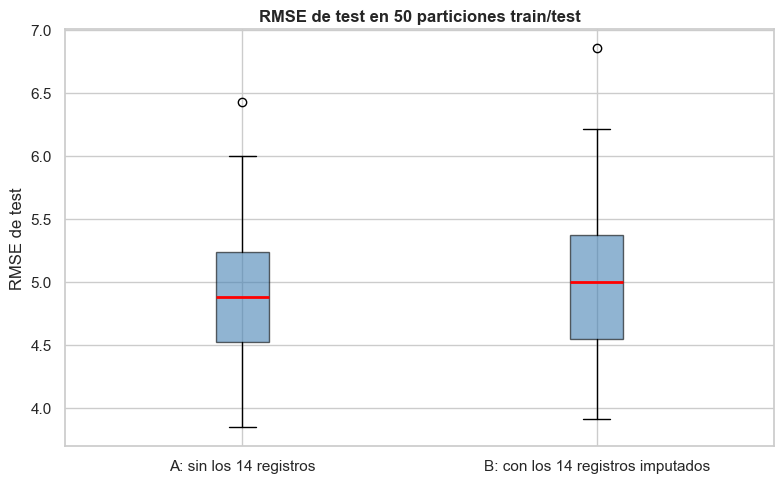

In [73]:
rmse_A = []
rmse_B = []

for semilla in range(50):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=semilla)

    # Escenario A
    modelo_A = LinearRegression().fit(X_tr, y_tr)
    rmse_A.append(np.sqrt(mean_squared_error(y_te, modelo_A.predict(X_te))))

    # Escenario B: KMeans se ajusta con el train de esta partición
    X_14_imp = imputar_kmeans(X_tr, filas_14[features], K_CHOSEN)
    modelo_B = LinearRegression().fit(pd.concat([X_tr, X_14_imp]), pd.concat([y_tr, y_14]))
    rmse_B.append(np.sqrt(mean_squared_error(y_te, modelo_B.predict(X_te))))

rmse_A = np.array(rmse_A)
rmse_B = np.array(rmse_B)

print(f'RMSE de test promedio - Escenario A: {rmse_A.mean():.3f} (desvío {rmse_A.std():.3f})')
print(f'RMSE de test promedio - Escenario B: {rmse_B.mean():.3f} (desvío {rmse_B.std():.3f})')
print(f'El escenario A tiene menor RMSE en {(rmse_A < rmse_B).sum()} de 50 particiones')

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([rmse_A, rmse_B], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
ax.set_xticks([1, 2], ['A: sin los 14 registros', 'B: con los 14 registros imputados'])
ax.set_ylabel('RMSE de test')
ax.set_title('RMSE de test en 50 particiones train/test', fontweight='bold')
plt.tight_layout()
plt.show()

In [74]:
resumen_escenarios = pd.DataFrame({
    'Escenario': ['A: sin los 14 registros', 'B: con los 14 registros imputados'],
    'RMSE test (random_state=42)': [RMSE_test_A, RMSE_test_B],
    'RMSE test promedio (50 particiones)': [rmse_A.mean(), rmse_B.mean()],
    'Particiones en que es mejor': [(rmse_A < rmse_B).sum(), (rmse_B < rmse_A).sum()]
}).round(3)
resumen_escenarios

,Escenario,RMSE test (random_state=42),RMSE test promedio (50 particiones),Particiones en que es mejor
0,A: sin los 14 registros,4.827,4.902,35
1,B: con los 14 registros imputados,4.722,5.037,15


**Conclusión de la validación.**

- Con una sola partición (`random_state=42`), el escenario B parecía levemente mejor.
- Con 50 particiones, el escenario A tiene menor RMSE en 35 de ellas, y su RMSE promedio es más bajo (4,90 contra 5,05). La ventaja de B en la primera partición fue producto de qué registros cayeron en ese test, no de un efecto real.

Esto muestra que no alcanza con comparar modelos en una sola partición: la diferencia entre A y B es menor que la variabilidad que genera la elección del split.

Sumado al diagnóstico de la sección 3, la evidencia indica que incorporar los registros imputados no mejora la predicción de viviendas reales y tiende a empeorarla. **Queda validada la decisión de eliminar los 50 registros con nulos.** De acá en adelante trabajamos solo con los registros completos, con la partición `X_train` / `X_test` de la sección 4.

---

## 6. Análisis descriptivo

A partir de esta sección analizamos **solo el conjunto de entrenamiento**, para no tomar decisiones de modelado mirando el test.

### 6.1 Medidas de tendencia central, dispersión, sesgo y curtosis


In [75]:
# DataFrame de entrenamiento con el target, para el análisis exploratorio
df_train = X_train.assign(MEDV=y_train)

desc = df_train.describe().T
desc['mediana'] = df_train.median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df_train.skew()
desc['curtosis'] = df_train.kurtosis()

print('Estadísticos descriptivos completos (train):')
print('=' * 80)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max', 'sesgo', 'curtosis']].round(3)

Estadísticos descriptivos completos (train):


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
CRIM,3.719,0.253,9.235,248.294,0.006,0.082,0.253,3.359,88.976,5.162,34.506
ZN,11.907,0.000,24.190,203.154,0.000,0.000,0.000,20.000,100.000,2.165,3.673
INDUS,10.986,9.690,6.876,62.590,0.460,5.085,9.690,18.100,27.740,0.328,-1.196
CHAS,0.059,0.000,0.237,398.405,0.000,0.000,0.000,0.000,1.000,3.742,12.060
NOX,0.553,0.538,0.118,21.262,0.385,0.448,0.538,0.624,0.871,0.767,-0.021
RM,6.312,6.218,0.725,11.491,3.561,5.889,6.218,6.644,8.780,0.413,1.786
AGE,67.864,76.250,28.198,41.550,2.900,43.250,76.250,94.100,100.000,-0.548,-1.016
DIS,3.833,3.276,2.138,55.773,1.130,2.101,3.276,5.213,12.126,1.022,0.543
RAD,9.371,5.000,8.638,92.176,1.000,4.000,5.000,24.000,24.000,1.045,-0.768
TAX,406.458,330.000,167.674,41.252,187.000,277.000,330.000,666.000,711.000,0.699,-1.097


In [76]:
# Calculamos el sesgo y la curtosis de todas las características para interpretarlos
print('Interpretación del Sesgo y Curtosis:')
print('=' * 60)

for col in cols_numericas:
    sesgo = df_train[col].skew()
    curtosis = df_train[col].kurtosis()

    # Clasificación del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simétrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificación de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocúrtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocúrtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicúrtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretación del Sesgo y Curtosis:
      CRIM: sesgo=+5.162 [sesgo positivo (alto)], curtosis=+34.506 [leptocúrtica (colas pesadas)]
        ZN: sesgo=+2.165 [sesgo positivo (alto)], curtosis=+3.673 [leptocúrtica (colas pesadas)]
     INDUS: sesgo=+0.328 [aproximadamente simétrica], curtosis=-1.196 [platicúrtica (colas livianas)]
      CHAS: sesgo=+3.742 [sesgo positivo (alto)], curtosis=+12.060 [leptocúrtica (colas pesadas)]
       NOX: sesgo=+0.767 [sesgo positivo (moderado)], curtosis=-0.021 [mesocúrtica]
        RM: sesgo=+0.413 [aproximadamente simétrica], curtosis=+1.786 [leptocúrtica (colas pesadas)]
       AGE: sesgo=-0.548 [sesgo negativo (moderado)], curtosis=-1.016 [platicúrtica (colas livianas)]
       DIS: sesgo=+1.022 [sesgo positivo (alto)], curtosis=+0.543 [leptocúrtica (colas pesadas)]
       RAD: sesgo=+1.045 [sesgo positivo (alto)], curtosis=-0.768 [platicúrtica (colas livianas)]
       TAX: sesgo=+0.699 [sesgo positivo (moderado)], curtosis=-1.097 [platicúrtica (c

### 6.2 Distribuciones

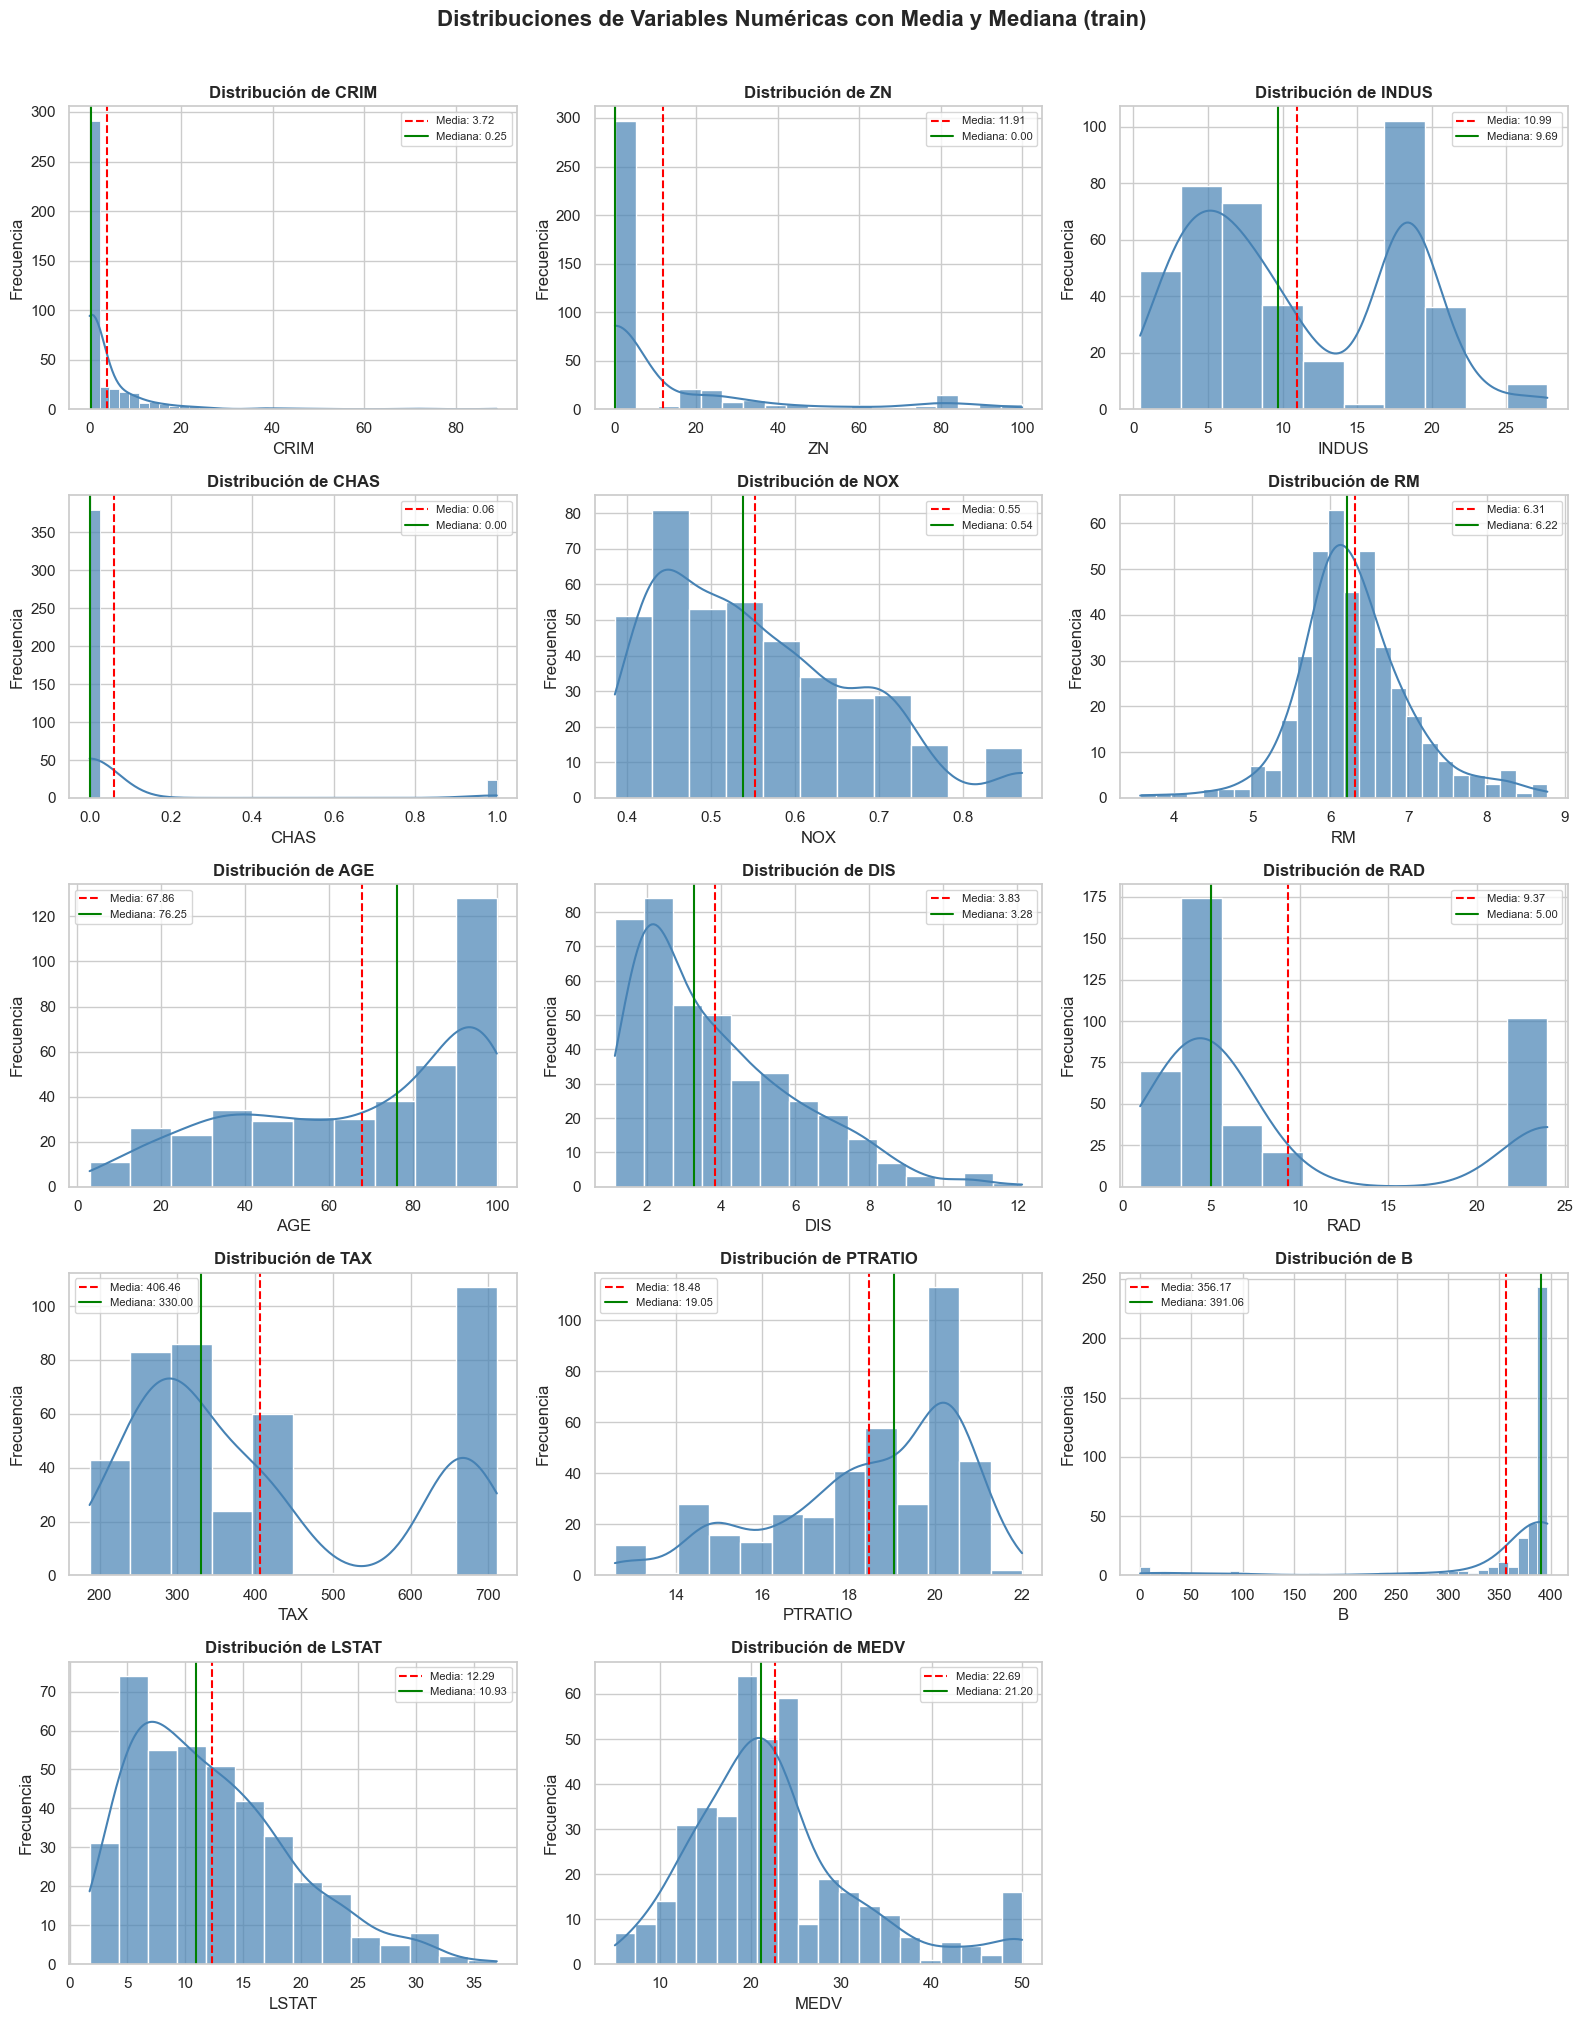

In [77]:
# Histogramas con estimación de densidad (KDE), media y mediana de cada variable
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    sns.histplot(df_train[col], kde=True, ax=ax, color='steelblue', edgecolor='white', alpha=0.7)

    # Líneas de referencia: media y mediana
    media = df_train[col].mean()
    mediana = df_train[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5, label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5, label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivar ejes sobrantes
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numéricas con Media y Mediana (train)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [78]:
# Variables discretas: frecuencia de cada valor
display(df_train["CHAS"].value_counts())
display(df_train["RAD"].value_counts())

CHAS
0.0    380
1.0     24
Name: count, dtype: int64

RAD
24.0    102
4.0      91
5.0      83
3.0      32
8.0      21
6.0      21
1.0      19
2.0      19
7.0      16
Name: count, dtype: int64

**Observaciones:**

- `CRIM`, `ZN` y `B` son las variables más asimétricas (`CRIM` con sesgo positivo alto, `B` con sesgo negativo alto). La mayoría de las zonas tiene criminalidad muy baja, y unas pocas la tienen muy alta.
- `MEDV` tiene sesgo positivo, y en su histograma se ve la acumulación en 50 que produce la censura (sección 3.7).
- En `CHAS`, el sesgo y la curtosis no deben interpretarse como en una variable continua: es binaria, y sus valores extremos solo reflejan que pocas zonas (24 de 404) limitan con el río.
- `RAD` tiene dos grupos claramente separados: valores entre 1 y 8, y el valor 24.

---

## 7. Pruebas de normalidad

- **Shapiro-Wilk:** contrasta $H_0$: la muestra proviene de una distribución normal.
- **D'Agostino-Pearson:** combina un test de sesgo y uno de curtosis en un estadístico $K^2 \sim \chi^2(2)$.

**Criterio de decisión:** si $p < \alpha$ ($\alpha = 0.05$), se rechaza $H_0$ y se concluye que la variable no sigue una distribución normal.

In [79]:
# Pruebas para analizar la normalidad de las variables
ALPHA = 0.05

resultados_normalidad = []

for col in cols_numericas:
    datos = df_train[col]

    stat_dag, p_dag = stats.normaltest(datos)   # D'Agostino-Pearson
    stat_shap, p_shap = stats.shapiro(datos)    # Shapiro-Wilk

    resultados_normalidad.append({
        'Variable': col,
        'Shapiro-W': stat_shap,
        'Shapiro-p': p_shap,
        'DAgostino-K2': stat_dag,
        'DAgostino-p': p_dag,
        'Normal (alpha=0.05)': 'Si' if (p_shap > ALPHA and p_dag > ALPHA) else 'No'
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print('Resultados de Pruebas de Normalidad:')
print('=' * 80)
df_normalidad

Resultados de Pruebas de Normalidad:


,Variable,Shapiro-W,Shapiro-p,DAgostino-K2,DAgostino-p,Normal (alpha=0.05)
0,CRIM,0.433105,1.047287e-33,451.551312,8.848681e-99,No
1,ZN,0.558899,1.225866e-30,177.325764,3.120323e-39,No
2,INDUS,0.899425,1.122216e-15,241.648856,3.362154e-53,No
3,CHAS,0.249920,2.594109e-37,328.136009,5.574051e-72,No
4,NOX,0.929129,6.526154e-13,32.785129,7.599755e-08,No
5,RM,0.961653,8.924641e-09,30.024614,3.021606e-07,No
6,AGE,0.898780,9.926823e-16,104.177572,2.388513e-23,No
7,DIS,0.902876,2.183564e-15,55.347317,9.582588e-13,No
8,RAD,0.681365,6.869995e-27,80.544929,3.235123e-18,No
9,TAX,0.815050,3.386568e-21,157.943360,5.047022e-35,No


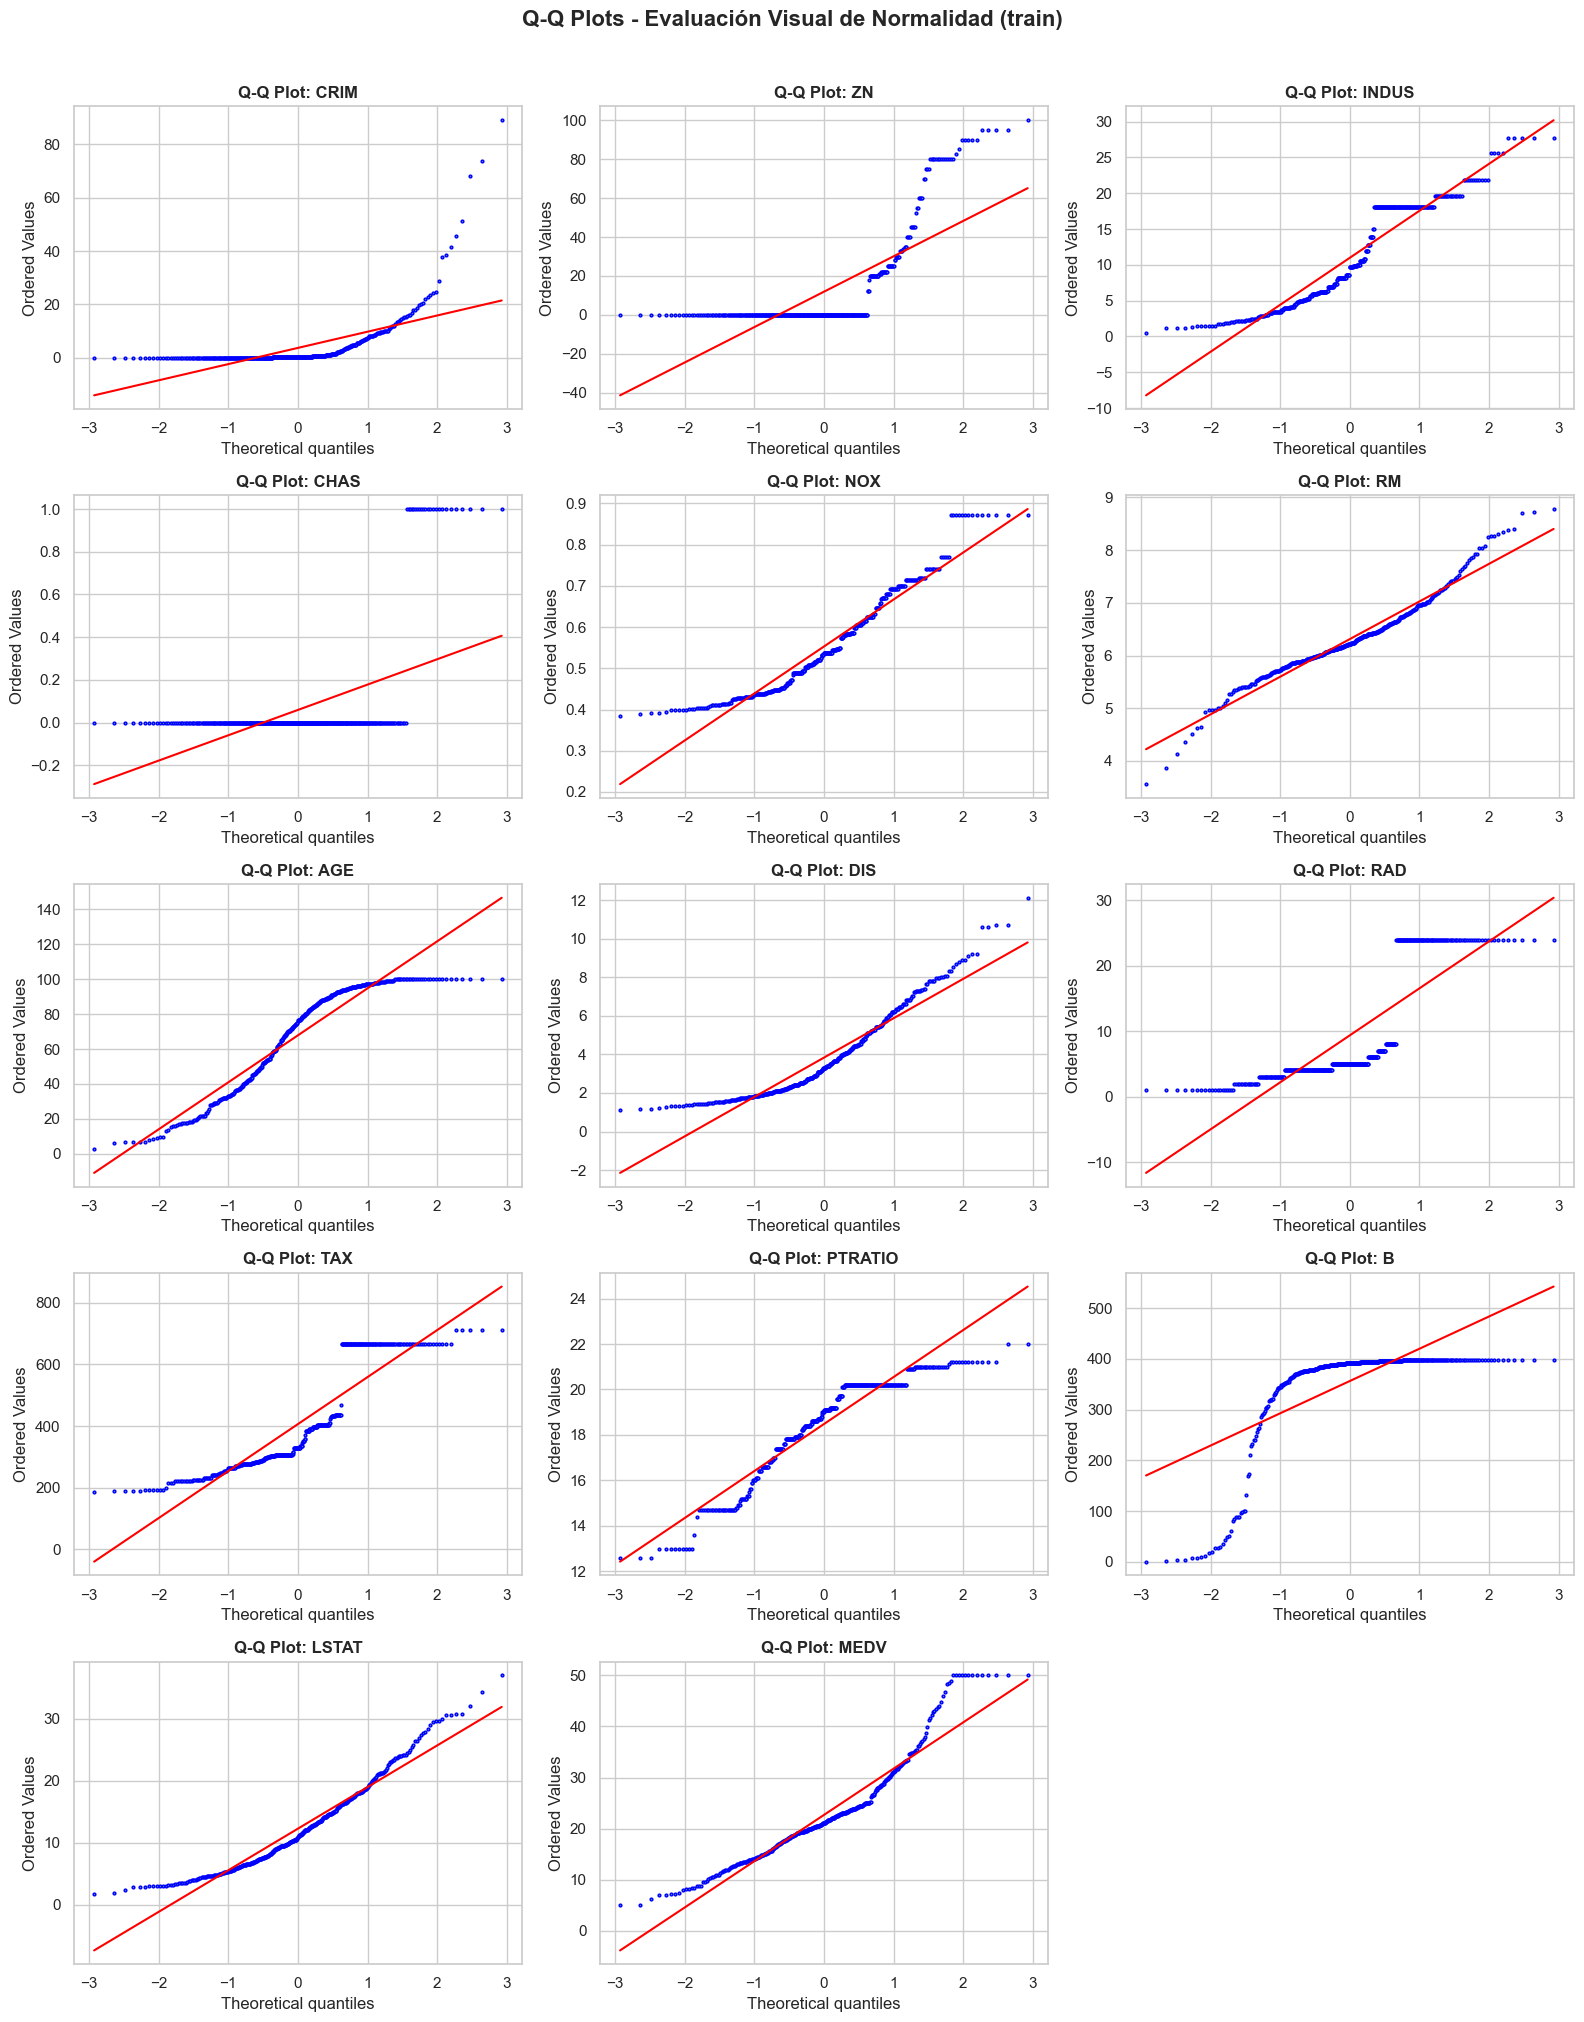

In [80]:
# Q-Q plots: evaluación visual de normalidad
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    stats.probplot(df_train[col], dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {col}', fontweight='bold')
    ax.get_lines()[0].set_markerfacecolor('steelblue')
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('red')

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots - Evaluación Visual de Normalidad (train)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observación:** ninguna variable supera los tests de normalidad, algo esperable en datos reales. Esto no impide usar regresión lineal: el modelo **no** requiere que las features sean normales. El supuesto de normalidad de la regresión lineal se refiere a los **residuos** del modelo, y lo vamos a revisar cuando entrenemos los modelos.

---

## 8. Correlaciones y colinealidad

- **Pearson** mide la fuerza de la relación **lineal** entre dos variables: $|r| < 0.3$ débil, $0.3 \leq |r| < 0.7$ moderada, $|r| \geq 0.7$ fuerte.
- **Spearman** es la correlación de Pearson aplicada sobre los rangos: capta relaciones **monótonas** y es robusta ante outliers.
- **Colinealidad:** dos features son colineales cuando $|r| \geq 0.85$. En un modelo lineal, la colinealidad vuelve inestables los coeficientes. 

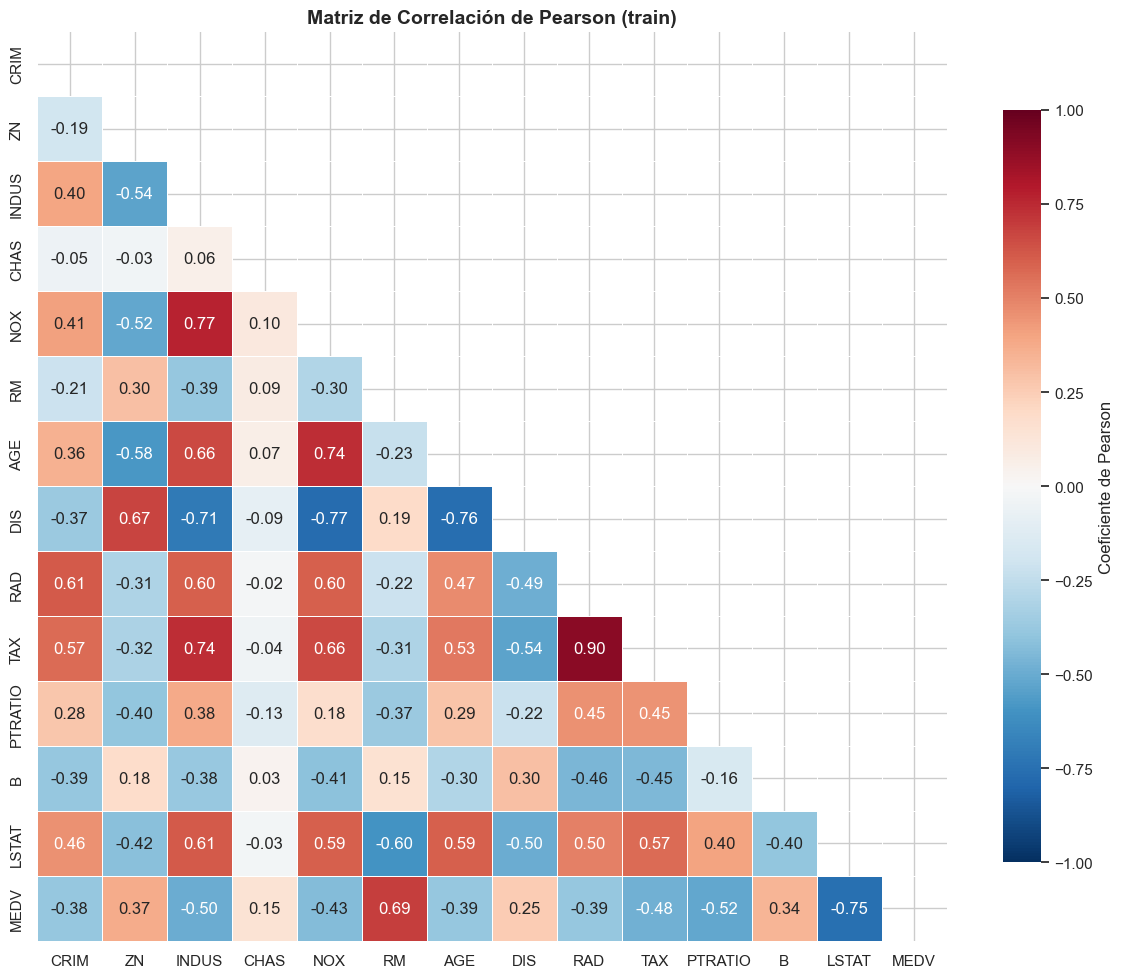

In [81]:
# Matriz de correlación de Pearson
corr_pearson = df_train.corr(method='pearson')

# Máscara triangular superior
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'})
ax.set_title('Matriz de Correlación de Pearson (train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

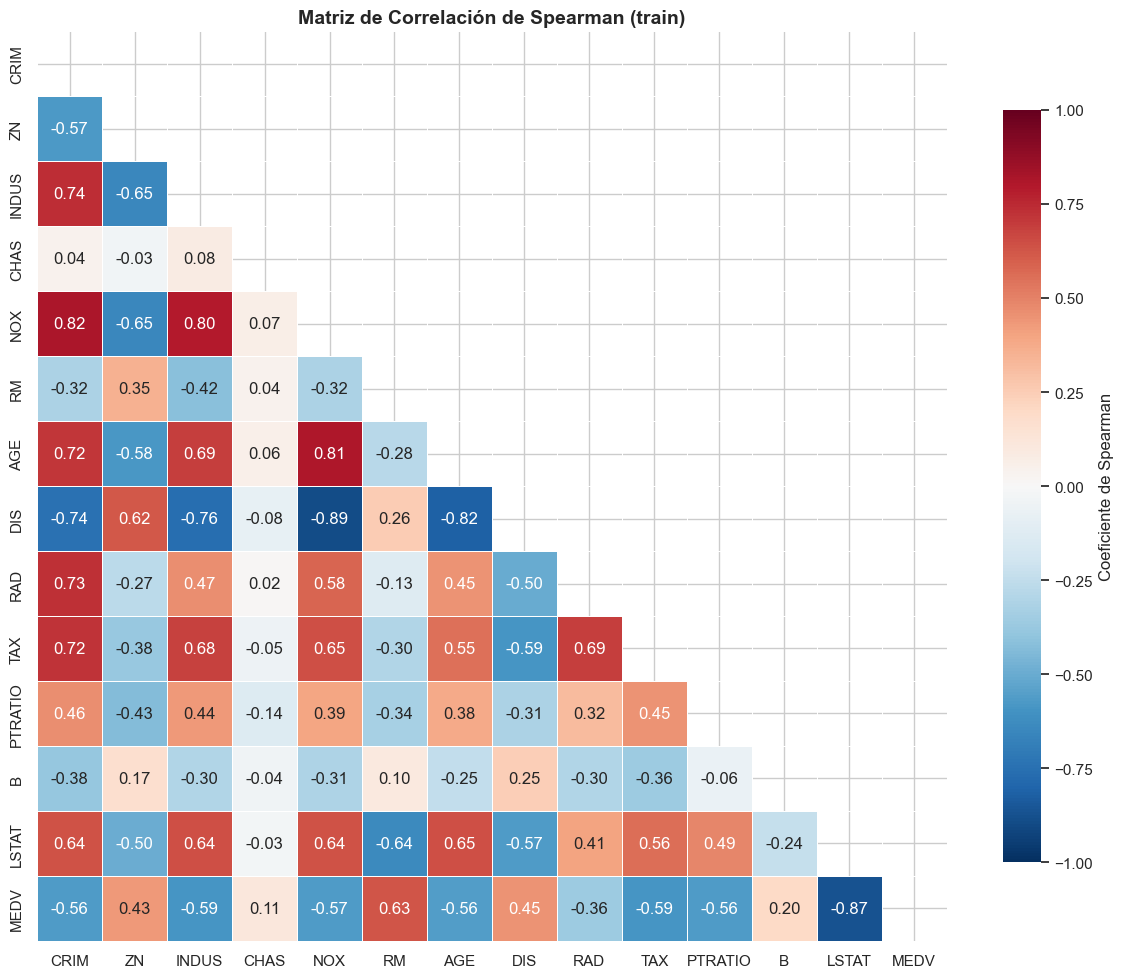

In [82]:
# Matriz de correlación de Spearman
corr_spearman = df_train.corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Spearman'})
ax.set_title('Matriz de Correlación de Spearman (train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [83]:
# Correlación de cada feature con el target, ordenada por intensidad
corr_target = corr_pearson['MEDV'].drop('MEDV')
corr_target.reindex(corr_target.abs().sort_values(ascending=False).index).round(3)

LSTAT     -0.753
RM         0.692
PTRATIO   -0.523
INDUS     -0.495
TAX       -0.481
NOX       -0.433
AGE       -0.386
RAD       -0.386
CRIM      -0.385
ZN         0.367
B          0.340
DIS        0.250
CHAS       0.147
Name: MEDV, dtype: float64

In [84]:
# Buscamos colinealidad entre pares de features
UMBRAL_COLINEALIDAD = 0.85
corr_features = corr_pearson.drop(index='MEDV', columns='MEDV')

print(f'Pares con |r_pearson| >= {UMBRAL_COLINEALIDAD} (posible colinealidad):')
print('=' * 60)

pares_colineales = []
for i in range(len(corr_features.columns)):
    for j in range(i + 1, len(corr_features.columns)):
        r = corr_features.iloc[i, j]
        if abs(r) >= UMBRAL_COLINEALIDAD:
            var1 = corr_features.columns[i]
            var2 = corr_features.columns[j]
            pares_colineales.append((var1, var2, r))
            print(f'  {var1} <-> {var2}: r = {r:.4f}')

if not pares_colineales:
    print('  No se detectaron pares con colinealidad severa.')

Pares con |r_pearson| >= 0.85 (posible colinealidad):
  RAD <-> TAX: r = 0.9003


In [85]:
# Variance Inflation Factor (VIF) de cada feature
vif_resultados = []
for col in X_train.columns:
    X_vif = X_train.drop(columns=[col])
    y_vif = X_train[col]

    r2 = LinearRegression().fit(X_vif, y_vif).score(X_vif, y_vif)
    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_resultados.append({'Variable': col, 'R2': r2, 'VIF': vif})

df_vif_result = pd.DataFrame(vif_resultados).sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print('=' * 50)
print('VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada')
print()
for _, row in df_vif_result.iterrows():
    alerta = '  << SEVERA' if row['VIF'] > 10 else ('  << MODERADA' if row['VIF'] > 5 else '')
    print(f"  {row['Variable']:>8s}: VIF = {row['VIF']:>6.2f}{alerta}")

Variance Inflation Factor (VIF):
VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada

       TAX: VIF =   8.94  << MODERADA
       RAD: VIF =   6.96  << MODERADA
       NOX: VIF =   4.53
     INDUS: VIF =   4.35
       DIS: VIF =   4.17
       AGE: VIF =   3.22
     LSTAT: VIF =   2.83
        ZN: VIF =   2.39
        RM: VIF =   1.85
   PTRATIO: VIF =   1.85
      CRIM: VIF =   1.75
         B: VIF =   1.40
      CHAS: VIF =   1.07


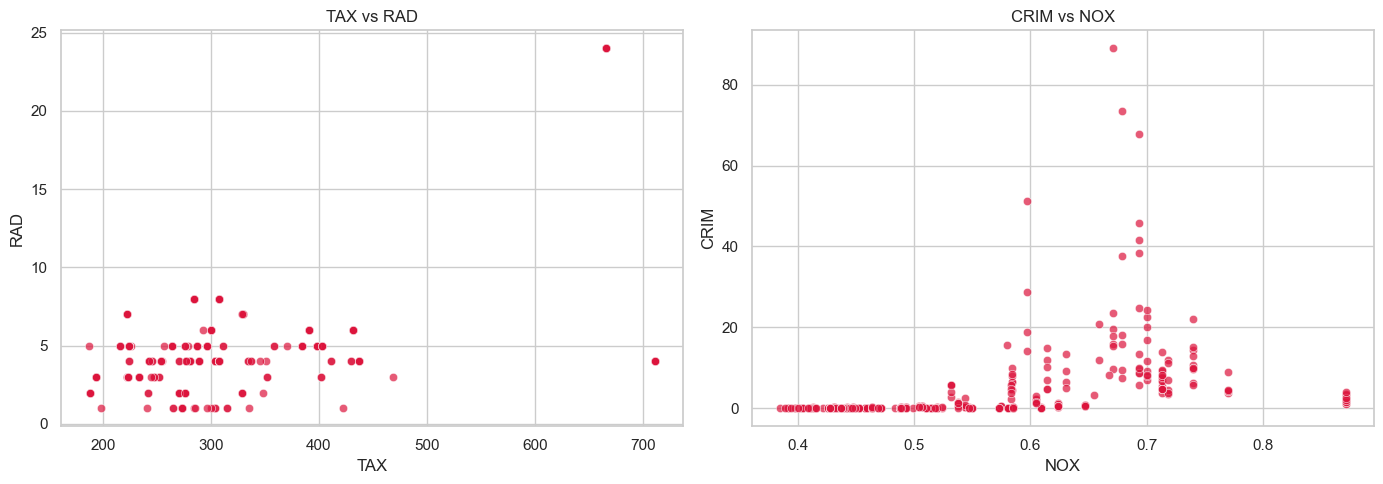

In [86]:
# Relación entre los pares de variables más correlacionados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=df_train["TAX"], y=df_train["RAD"], ax=axes[0], alpha=0.7, color="crimson")
axes[0].set_title("TAX vs RAD")

sns.scatterplot(x=df_train["NOX"], y=df_train["CRIM"], ax=axes[1], alpha=0.7, color="crimson")
axes[1].set_title("CRIM vs NOX")

plt.tight_layout()
plt.show()

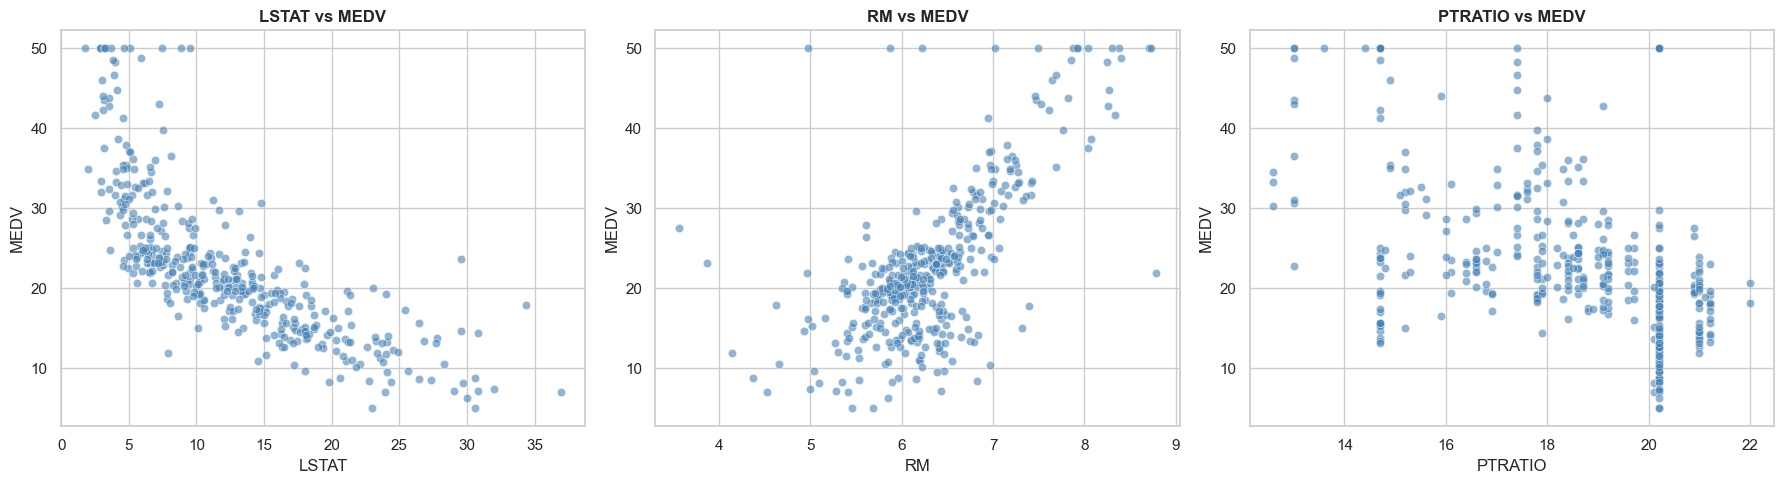

In [87]:
# Relación de las features más correlacionadas con el target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['LSTAT', 'RM', 'PTRATIO']):
    sns.scatterplot(x=df_train[col], y=df_train['MEDV'], ax=ax, alpha=0.6, color='steelblue')
    ax.set_title(f'{col} vs MEDV', fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**

- Las features más correlacionadas con el precio son `LSTAT` (−0,75) y `RM` (+0,69): a mayor proporción de población de menor estatus socioeconómico, menor precio; a más habitaciones, mayor precio. Le siguen `PTRATIO`, `INDUS` y `TAX`, con correlaciones negativas moderadas.
- En el scatter de `LSTAT` vs `MEDV` la relación no es del todo lineal (es curva). También se ve la línea horizontal de registros en `MEDV` = 50 que produce la censura.
- `RAD` y `TAX` son colineales ($r = 0.90$), y son las features con mayor VIF. En el gráfico se ve que la correlación está dominada por un grupo de zonas con `RAD` = 24 y `TAX` cercano a 666. Hay además correlaciones fuertes entre `NOX`, `INDUS`, `AGE` y `DIS`.
- La colinealidad no afecta la capacidad predictiva de la regresión lineal, pero vuelve inestables sus coeficientes. Es un punto a tener en cuenta en la consigna 4: la regularización Ridge está pensada justamente para este problema.

---

## 9. Detección de outliers

- **Método IQR:** un valor es outlier si está por fuera de $[Q_1 - 1.5 \cdot IQR, \; Q_3 + 1.5 \cdot IQR]$. No asume normalidad.
- **Método Z-score:** un valor es outlier si $|z_i| > 3$. Asume una distribución aproximadamente normal.

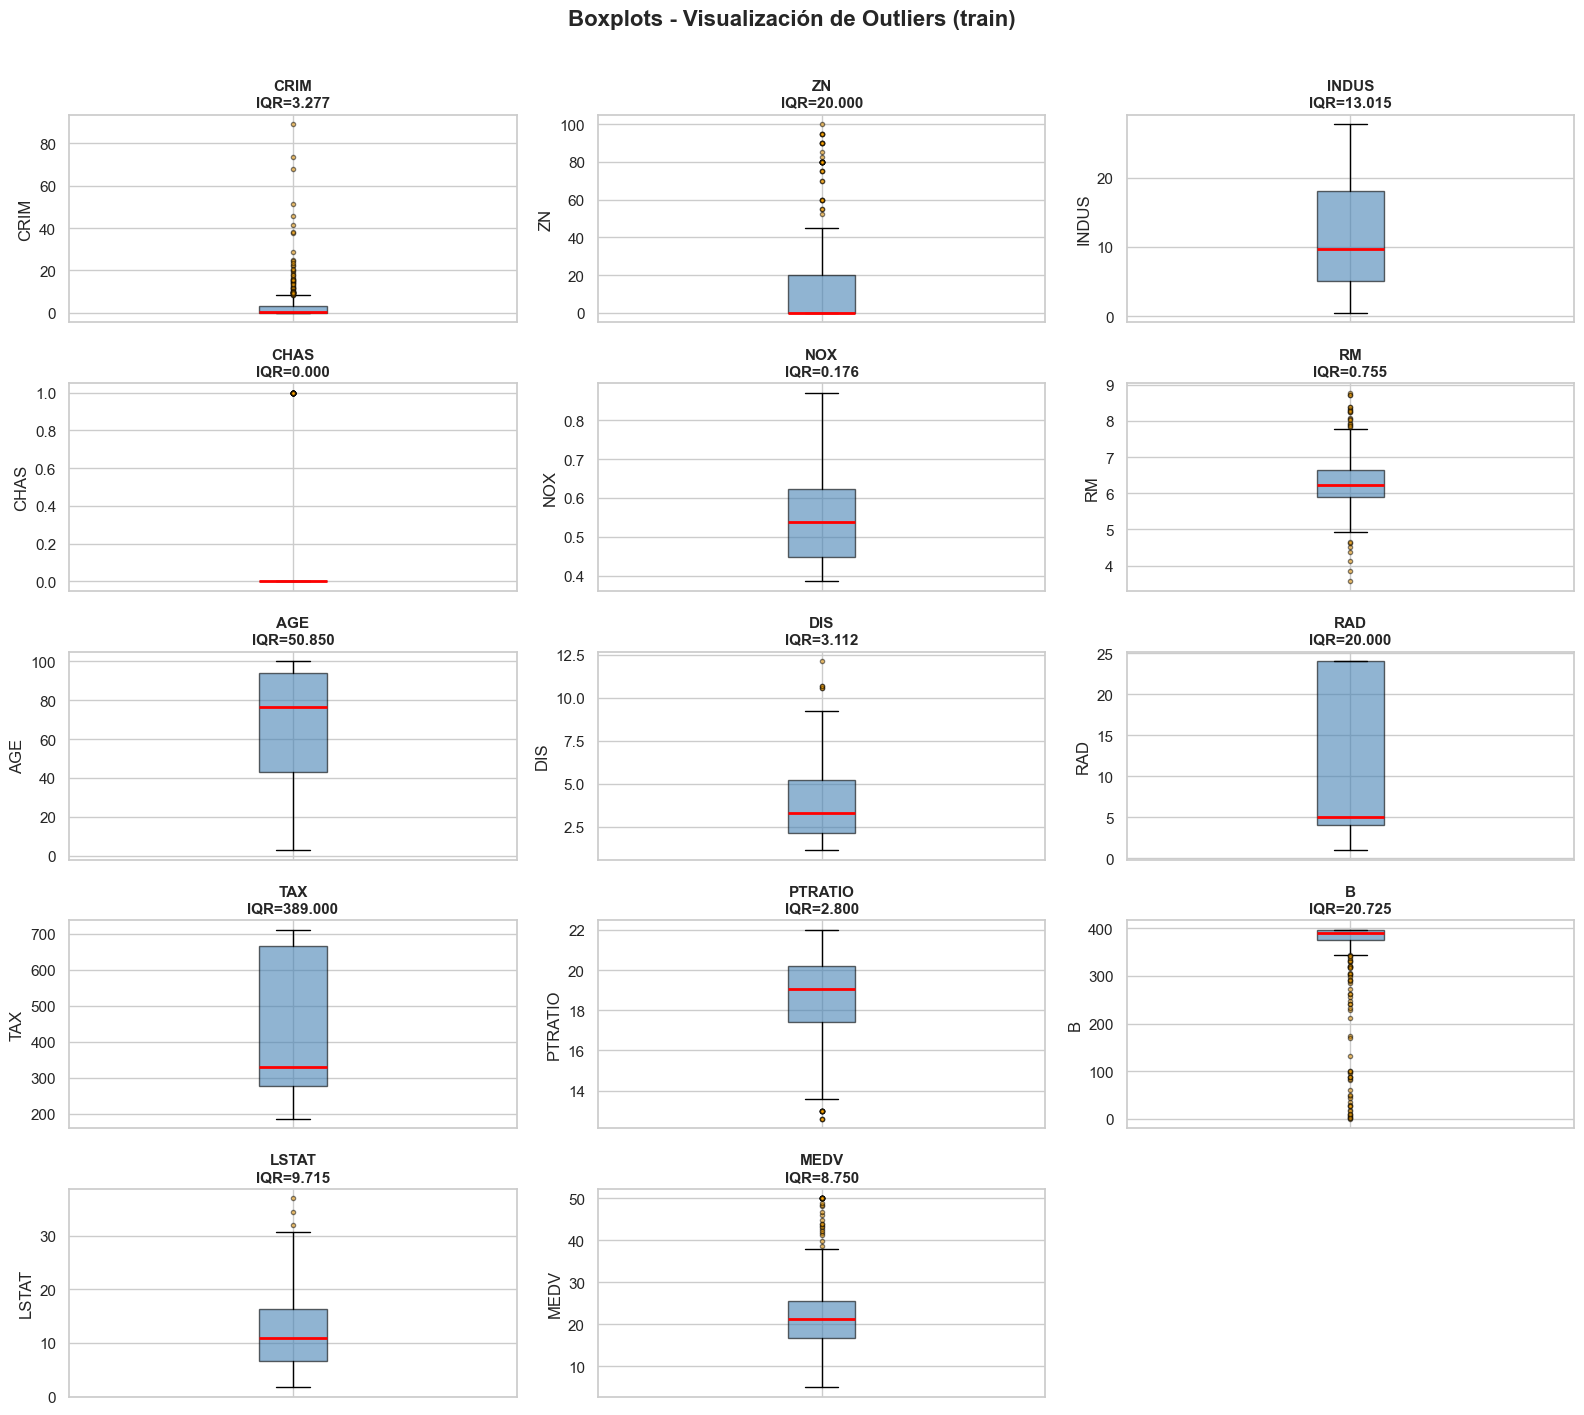

In [88]:
# Boxplots de cada variable para visualizar valores atípicos
fig, axes = plt.subplots(5, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df_train[col]

    ax.boxplot(datos, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='orange', markersize=3, alpha=0.5))

    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    ax.set_title(f'{col}\nIQR={q3 - q1:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualización de Outliers (train)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [89]:
# Reporte de outliers por los métodos IQR y Z-score
Z_THRESHOLD = 3.0
IQR_FACTOR = 1.5

reporte_outliers = []

for col in cols_numericas:
    datos = df_train[col]
    n = len(datos)

    # Método IQR
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    outliers_iqr = ((datos < q1 - IQR_FACTOR * iqr) | (datos > q3 + IQR_FACTOR * iqr)).sum()

    # Método Z-score
    outliers_zscore = (np.abs(stats.zscore(datos)) > Z_THRESHOLD).sum()

    reporte_outliers.append({
        'Variable': col,
        'Outliers_IQR': outliers_iqr,
        'Pct_IQR(%)': outliers_iqr / n * 100,
        'Outliers_ZScore': outliers_zscore,
        'Pct_ZScore(%)': outliers_zscore / n * 100
    })

df_outliers = pd.DataFrame(reporte_outliers)
print('Reporte de Outliers: Método IQR vs Z-Score (train)')
print('=' * 70)
df_outliers.round(2)

Reporte de Outliers: Método IQR vs Z-Score (train)


,Variable,Outliers_IQR,Pct_IQR(%),Outliers_ZScore,Pct_ZScore(%)
0,CRIM,56,13.86,8,1.98
1,ZN,38,9.41,11,2.72
2,INDUS,0,0.00,0,0.00
3,CHAS,24,5.94,24,5.94
4,NOX,0,0.00,0,0.00
5,RM,25,6.19,6,1.49
6,AGE,0,0.00,0,0.00
7,DIS,5,1.24,5,1.24
8,RAD,0,0.00,0,0.00
9,TAX,0,0.00,0,0.00


**Observaciones y decisión:**

- Las variables con más outliers son `B`, `CRIM` y `ZN`, que son las más asimétricas. En distribuciones con sesgo alto, el método IQR marca como outliers muchos valores que son parte de la cola natural de la distribución.
- En `CHAS`, los "outliers" son simplemente las 24 zonas que limitan con el río: al ser binaria, cualquier valor 1 queda fuera de los bigotes.
- En `MEDV`, parte de los outliers son los registros censurados en 50.

**Decisión: no eliminamos outliers.** Son valores posibles de viviendas reales (zonas con criminalidad muy alta, casas muy caras) y no errores de carga, que ya tratamos en la sección 3. Eliminarlos reduciría la capacidad del modelo de predecir justamente esos casos.

---

## 10. Estandarización

La **estandarización** transforma cada variable para que tenga media 0 y desvío estándar 1:

- **Gradiente descendente:** con variables en escalas muy distintas (`TAX` en cientos, `NOX` menor que 1), la función de costo queda muy alargada y el algoritmo converge lento o no converge.
- **Regularización (Lasso, Ridge, Elastic Net):** la penalización se aplica sobre el tamaño de los coeficientes, y ese tamaño depende de la escala de cada variable. Sin estandarizar, la penalización afectaría más a unas variables que a otras.

El `StandardScaler` se ajusta (`fit`) **solo con el conjunto de entrenamiento**, y con esa media y ese desvío se transforman el train y el test. Si se ajustara con todos los datos, la información del test se filtraría al modelo.

In [90]:
scaler = RobustScaler()

# Ajustamos (fit) y transformamos ÚNICAMENTE con el conjunto de entrenamiento
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

# Aplicamos la media y el desvío del train sobre el conjunto de prueba (solo transform)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print('Verificación post-estandarización (train):')
print('=' * 50)
verificacion = pd.DataFrame({
    'Media': X_train_scaled.mean(),
    'Std': X_train_scaled.std(),
    'Min': X_train_scaled.min(),
    'Max': X_train_scaled.max()
}).round(4)
print(verificacion)
print()
print('Media ~ 0 y Std ~ 1 en train: estandarización correcta.')

Verificación post-estandarización (train):
          Media     Std      Min      Max
CRIM     1.0577  2.8178  -0.0752  27.0713
ZN       0.5954  1.2095   0.0000   5.0000
INDUS    0.0995  0.5283  -0.7092   1.3869
CHAS     0.0594  0.2367   0.0000   1.0000
NOX      0.0834  0.6677  -0.8693   1.8920
RM       0.1255  0.9607  -3.5185   3.3940
AGE     -0.1649  0.5545  -1.4425   0.4671
DIS      0.1790  0.6869  -0.6897   2.8440
RAD      0.2186  0.4319  -0.2000   0.9500
TAX      0.1965  0.4310  -0.3676   0.9794
PTRATIO -0.2049  0.7712  -2.3036   1.0536
B       -1.6835  4.3875 -18.8538   0.2815
LSTAT    0.1400  0.7078  -0.9465   2.6819

Media ~ 0 y Std ~ 1 en train: estandarización correcta.


In [91]:
# En el test la media y el desvío no son exactamente 0 y 1: es lo esperado,
# porque se transformó con los parámetros aprendidos del train
pd.DataFrame({'Media test': X_test_scaled.mean(), 'Std test': X_test_scaled.std()}).round(3).T

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
Media test,0.897,0.461,0.157,0.108,0.140,-0.056,-0.096,0.118,0.263,0.219,-0.242,-1.564,0.328
Std test,1.655,0.973,0.522,0.312,0.621,0.788,0.549,0.635,0.449,0.444,0.784,4.494,0.821


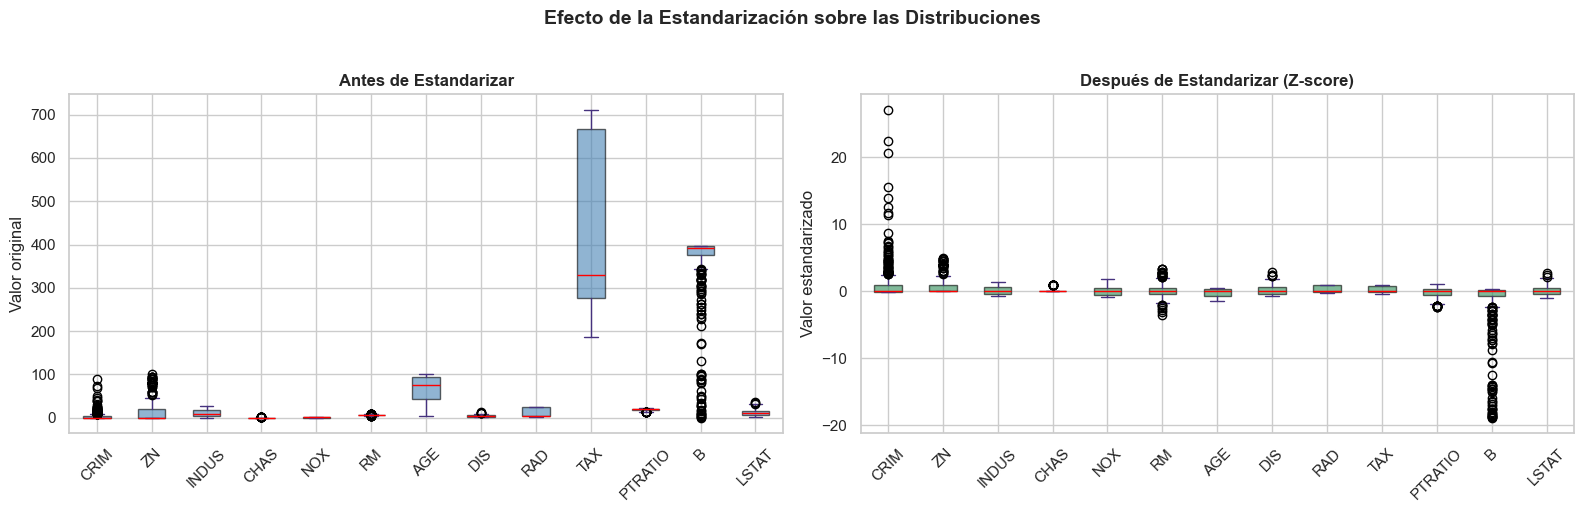

In [92]:
# Efecto de la estandarización sobre las distribuciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

X_train.plot.box(ax=axes[0], patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6), medianprops=dict(color='red'))
axes[0].set_title('Antes de Estandarizar', fontweight='bold')
axes[0].set_ylabel('Valor original')
axes[0].tick_params(axis='x', rotation=45)

X_train_scaled.plot.box(ax=axes[1], patch_artist=True,
                        boxprops=dict(facecolor='seagreen', alpha=0.6), medianprops=dict(color='red'))
axes[1].set_title('Después de Estandarizar (Z-score)', fontweight='bold')
axes[1].set_ylabel('Valor estandarizado')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Efecto de la Estandarización sobre las Distribuciones', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 11. Conclusiones y próximos pasos

### Hallazgos principales

1. **Calidad de datos:** el dataset original tenía 556 registros. Los 306 valores faltantes se concentraban en 50 registros que, además, contenían valores imposibles de `RAD`, y relaciones con el precio incompatibles con las demás viviendas. Los identificamos como registros corruptos y los eliminamos, quedándonos con 506 registros completos.
2. **Validación de la eliminación:** conservar e imputar con KMeans los 14 registros que admitía un criterio más conservador no mejora el modelo. En 50 particiones distintas, entrenar sin ellos da menor RMSE en 35 de 50 casos. También vimos que evaluar en una sola partición puede llevar a una conclusión equivocada.
3. **Censura:** `MEDV` está censurada en 50. Esperamos que los modelos subestimen las viviendas más caras.
4. **Distribuciones:** ninguna variable es normal; `CRIM`, `ZN` y `B` son muy asimétricas. No eliminamos outliers porque corresponden a viviendas reales.
5. **Correlaciones:** `LSTAT` y `RM` son las variables más relacionadas con el precio. `RAD` y `TAX` son colineales ($r = 0.90$).
6. **Preprocesamiento:** no hay variables categóricas que codificar. Los datos quedan divididos en train (404) y test (102), y estandarizados con los parámetros del train.

### Próximos pasos: consigna 4

- Regresión lineal múltiple con `LinearRegression`, con métricas en train y test.
- Gradiente descendente (`SGDRegressor`), con gráficos de error vs. épocas.
- Regularización: Lasso, Ridge y Elastic Net.
- Análisis de residuos, para revisar el efecto de la censura de `MEDV`.